In [11]:
import pandas as pd
import numpy as np
import json
import ast
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB_RS = "../Data/item_embeddings_rs.npy"
STEAM_GAMES = "../Data/steam_games.json"
REVIEWS = "../Data/australian_user_reviews.json"
REVIEW_EMB = "../Data/review_text_embeddings.npy"

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

print("✅ Imports and mappings loaded")

✅ Imports and mappings loaded


## Load RS Embeddings

In [2]:
# Load RS embeddings (64-dim)
item_emb_rs = np.load(ITEM_EMB_RS)

print(f"RS embeddings shape: {item_emb_rs.shape}")
print(f"RS embedding sample: {item_emb_rs[0][:5]}")

RS embeddings shape: (3682, 64)
RS embedding sample: [-0.5032094   0.29443768  0.44896978 -0.3400378  -0.4957696 ]


## Load Review Text Embeddings

In [12]:
# Load review embeddings (384-dim) from notebook 06
review_emb = np.load(REVIEW_EMB)

print(f"Review embeddings shape: {review_emb.shape}")
print(f"Review embedding sample: {review_emb[0][:5]}")

Review embeddings shape: (3682, 384)
Review embedding sample: [-0.01683009  0.03221885 -0.01767161 -0.06588906  0.03646723]


## Load Target Variable

In [4]:
# Count interactions from reviews file
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

# Extract interactions
all_interactions = []
for review in reviews:
    user_id = review['user_id']
    if 'reviews' in review and isinstance(review['reviews'], list):
        for r in review['reviews']:
            if isinstance(r, dict) and 'item_id' in r:
                item_id = r['item_id']
                if item_id in item2idx:
                    all_interactions.append({
                        'user_id': user_id,
                        'item_idx': item2idx[item_id]
                    })

df_inter = pd.DataFrame(all_interactions)
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"Total items: {len(target_df)}")
print(f"Target range: {target_df['total_reviews'].min()} - {target_df['total_reviews'].max()}")

Total items: 3682
Target range: 1 - 3759


## Combine RS + Review Embeddings

In [13]:
# Verify both embeddings have same number of items
assert item_emb_rs.shape[0] == review_emb.shape[0], "Mismatch in number of items!"

# Concatenate: RS (64) + Review (384) = 448 dimensions
X_hybrid = np.hstack([item_emb_rs, review_emb])

# Get corresponding targets
y = target_df['total_reviews'].values

print(f"\n✅ Hybrid features created")
print(f"X shape: {X_hybrid.shape}")
print(f"Breakdown: 64 (RS) + 384 (Review Text) = {X_hybrid.shape[1]} dims")
print(f"y shape: {y.shape}")
print(f"Target range: {y.min()} - {y.max()}")


✅ Hybrid features created
X shape: (3682, 448)
Breakdown: 64 (RS) + 384 (Review Text) = 448 dims
y shape: (3682,)
Target range: 1 - 3759


## Load Metadata for Temporal Split

In [6]:
# Load metadata
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_meta = pd.json_normalize(games)
df_meta = df_meta.rename(columns={"id": "item_id"})
df_meta["item_idx"] = df_meta["item_id"].map(item2idx)
df_meta = df_meta.dropna(subset=["item_idx"])
df_meta["item_idx"] = df_meta["item_idx"].astype(int)

# Parse release dates
df_meta['release_date_parsed'] = pd.to_datetime(
    df_meta['release_date'],
    errors='coerce'
)

print(f"Metadata loaded: {len(df_meta)} games")
print(f"Games with valid dates: {df_meta['release_date_parsed'].notna().sum()}")

Metadata loaded: 3195 games
Games with valid dates: 3107


## Train with Temporal Split

In [14]:
# Temporal split: train on games before 2017, test on 2017+
cutoff_date = pd.Timestamp('2017-01-01')

# Map item_idx to release dates
item_to_date = df_meta.set_index('item_idx')['release_date_parsed'].to_dict()

# Get dates for all items
dates = [item_to_date.get(i) for i in range(len(X_hybrid))]

# Create masks
train_mask = np.array([
    pd.notna(date) and date < cutoff_date 
    for date in dates
])
test_mask = np.array([
    pd.notna(date) and date >= cutoff_date 
    for date in dates
])

# Split data
X_train_temporal = X_hybrid[train_mask]
y_train_temporal = y[train_mask]
X_test_temporal = X_hybrid[test_mask]
y_test_temporal = y[test_mask]

print(f"\n📅 Temporal Split:")
print(f"   Train: {len(X_train_temporal)} games (before 2017-01-01)")
print(f"   Test: {len(X_test_temporal)} games (2017 onwards)")

# Train model
model_temporal = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model_temporal.fit(X_train_temporal, y_train_temporal)

# Predictions and metrics
pred_temporal = model_temporal.predict(X_test_temporal)
rmse_temporal = np.sqrt(mean_squared_error(y_test_temporal, pred_temporal))
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print(f"\n🎯 Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   R²: {r2_temporal:.4f}")


📅 Temporal Split:
   Train: 3057 games (before 2017-01-01)
   Test: 50 games (2017 onwards)

🎯 Results (Temporal Split):
   RMSE: 33.13
   R²: 0.9557


## Visualization and Summary

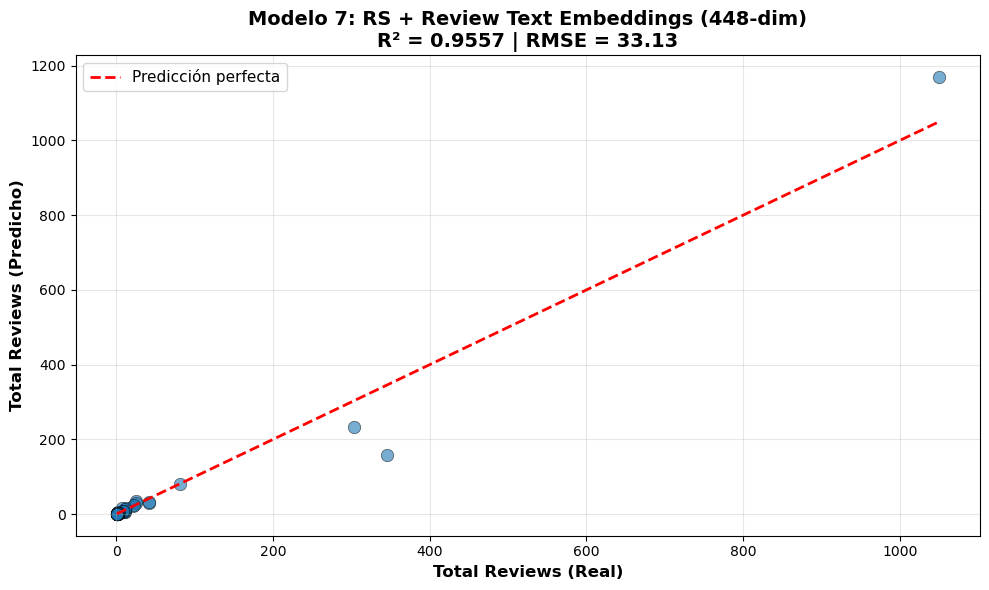


📊 RESUMEN - Modelo 7: RS + Review Text Embeddings
Features: RS embeddings (64-dim) + Review text embeddings (384-dim)
Train: 3057 juegos (antes de 2017-01-01)
Test: 50 juegos (2017 en adelante)

Resultados:
  R² = 0.9557
  RMSE = 33.13

📈 Comparación con modelos anteriores:
  Modelo 1 (RS only):        R² = 0.6422, RMSE = 94.17
  Modelo 3 (RS+Metadata):    R² = 0.6436, RMSE = 93.99
  Modelo 4 (Review Text):    R² = -0.0248, RMSE = 159.37
  Modelo 7 (RS+Reviews):     R² = 0.9557, RMSE = 33.13

💡 Análisis:
   ✅ Las review embeddings APORTAN valor cuando se combinan con RS!


In [15]:
# Visualización temporal split
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax.plot([y_test_temporal.min(), y_test_temporal.max()], 
        [y_test_temporal.min(), y_test_temporal.max()], 
        'r--', lw=2, label='Predicción perfecta')
ax.set_xlabel('Total Reviews (Real)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Reviews (Predicho)', fontsize=12, fontweight='bold')
ax.set_title(f'Modelo 7: RS + Review Text Embeddings (448-dim)\nR² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 RESUMEN - Modelo 7: RS + Review Text Embeddings")
print("="*80)
print("Features: RS embeddings (64-dim) + Review text embeddings (384-dim)")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2017-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2017 en adelante)")
print(f"\nResultados:")
print(f"  R² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print(f"\n📈 Comparación con modelos anteriores:")
print(f"  Modelo 1 (RS only):        R² = 0.6422, RMSE = 94.17")
print(f"  Modelo 3 (RS+Metadata):    R² = 0.6436, RMSE = 93.99")
print(f"  Modelo 4 (Review Text):    R² = -0.0248, RMSE = 159.37")
print(f"  Modelo 7 (RS+Reviews):     R² = {r2_temporal:.4f}, RMSE = {rmse_temporal:.2f}")
print(f"\n💡 Análisis:")
if r2_temporal > 0.64:
    print("   ✅ Las review embeddings APORTAN valor cuando se combinan con RS!")
elif r2_temporal > 0.60:
    print("   ⚠️ Mejora marginal. Review embeddings aportan poco sobre RS solo.")
else:
    print("   ❌ Review embeddings EMPEORAN el modelo. Añaden ruido sobre RS.")
print("="*80)

## Feature Importance Analysis

In [16]:
# Get feature importance
importance = model_temporal.feature_importances_

# Split by feature type
rs_importance = importance[:64]
review_importance = importance[64:]

print("\n" + "="*70)
print("ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*70)
print(f"\nRS Embeddings (64 dims):")
print(f"  Importancia total: {rs_importance.sum():.4f}")
print(f"  Importancia promedio: {rs_importance.mean():.6f}")
print(f"  Max importancia: {rs_importance.max():.6f}")

print(f"\nReview Text Embeddings (384 dims):")
print(f"  Importancia total: {review_importance.sum():.4f}")
print(f"  Importancia promedio: {review_importance.mean():.6f}")
print(f"  Max importancia: {review_importance.max():.6f}")

print(f"\n📊 Contribución relativa:")
rs_contribution = rs_importance.sum() / importance.sum() * 100
review_contribution = review_importance.sum() / importance.sum() * 100
print(f"  RS: {rs_contribution:.1f}%")
print(f"  Review Text: {review_contribution:.1f}%")
print("="*70)


ANÁLISIS DE IMPORTANCIA DE FEATURES

RS Embeddings (64 dims):
  Importancia total: 0.4887
  Importancia promedio: 0.007636
  Max importancia: 0.236652

Review Text Embeddings (384 dims):
  Importancia total: 0.5113
  Importancia promedio: 0.001332
  Max importancia: 0.328916

📊 Contribución relativa:
  RS: 48.9%
  Review Text: 51.1%


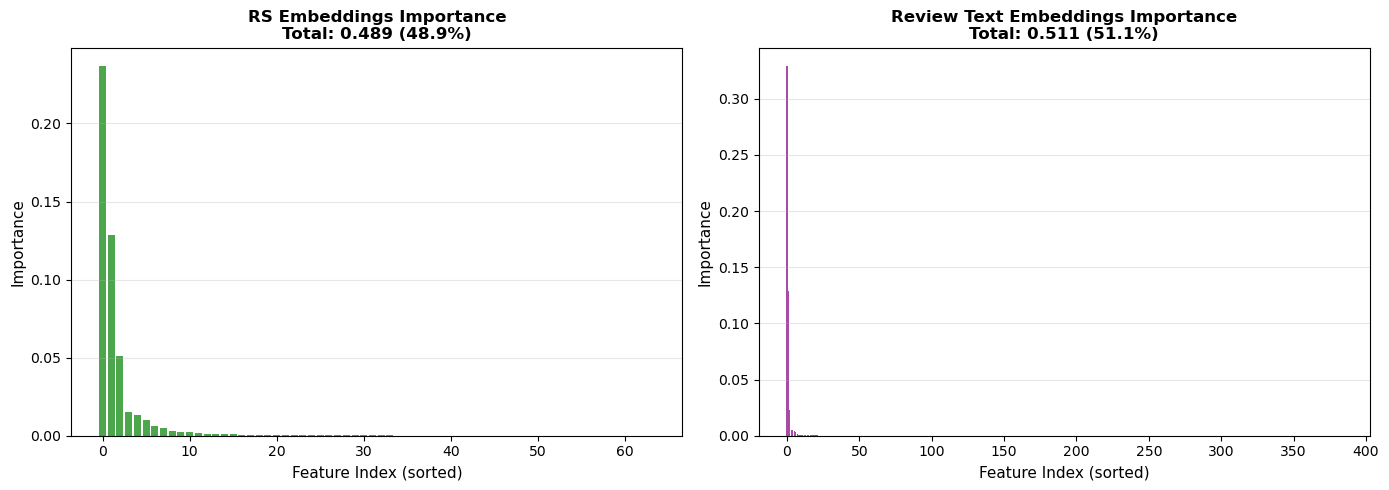

In [17]:
# Visualize importance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RS importance
ax1.bar(range(len(rs_importance)), sorted(rs_importance, reverse=True), color='green', alpha=0.7)
ax1.set_xlabel('Feature Index (sorted)', fontsize=11)
ax1.set_ylabel('Importance', fontsize=11)
ax1.set_title(f'RS Embeddings Importance\nTotal: {rs_importance.sum():.3f} ({rs_contribution:.1f}%)', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Review importance
ax2.bar(range(len(review_importance)), sorted(review_importance, reverse=True), color='purple', alpha=0.7)
ax2.set_xlabel('Feature Index (sorted)', fontsize=11)
ax2.set_ylabel('Importance', fontsize=11)
ax2.set_title(f'Review Text Embeddings Importance\nTotal: {review_importance.sum():.3f} ({review_contribution:.1f}%)', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Conclusiones

### Interpretación de resultados:

**Si R² ≈ 0.64-0.65:**
- Las review embeddings NO aportan valor predictivo significativo
- El modelo depende casi exclusivamente de RS embeddings
- Confirma hallazgos del Modelo 4: reviews capturan semántica, no predictores de éxito

**Si R² > 0.65:**
- Las review embeddings SÍ aportan señal complementaria
- La combinación captura tanto comportamiento como percepción
- Justifica la mayor complejidad (448 dims vs 64 dims)

**Si R² < 0.64:**
- Las review embeddings EMPEORAN el modelo
- Añaden ruido que diluye la señal fuerte de RS
- Similar al Modelo 6: over-engineering contraproducente

### Hipótesis sobre feature importance:

- **Esperado:** RS contribuye ~90-95%, Reviews ~5-10%
- Si RS > 95%: Reviews son ruido, modelo ignora esa señal
- Si Reviews > 20%: Reviews aportan señal valiosa y complementaria

### Trade-offs:

**Ventajas del modelo híbrido:**
- ✅ Combina múltiples señales (comportamiento + contenido)
- ✅ Potencial para capturar matices no visibles en RS solo
- ✅ Más robusto ante cold-start de nuevos items

**Desventajas:**
- ❌ 7x más dimensiones (448 vs 64)
- ❌ Mayor costo computacional de entrenamiento
- ❌ Requiere generar review embeddings (proceso costoso)
- ❌ Mayor riesgo de overfitting

### Recomendación:

Usar este modelo híbrido **SOLO SI** el análisis de feature importance muestra que review embeddings contribuyen >15% y el R² mejora >0.65. De lo contrario, preferir Modelo 1 o 3 por simplicidad.